In [1]:
import pandas as pd

In [2]:
# Load the required files
vote_sessions = pd.read_csv("../data/vote_sessions_full.csv", usecols=["id", "data", "aprovacao", "propositionID", "siglaOrgao", "year", "author_type", "num_authors", "theme", "legislatura", "Governo", "Oposição", "GOV."])
content_cluster = pd.read_csv("../Content/prop_content.csv", usecols=["id", "content"])
authors_pop = pd.read_csv("../Author's Popularity/author_popularity.csv", usecols=["idVotacao", "popularity"])
authors_comm = pd.read_csv("../Author's Group/authors_community_dataset_one_year_window.csv", usecols=["id", "author_prev_community", "prev_community_0_size", "prev_community_1_size", "prev_community_2_size"])

# Merge vote_sessions with content_cluster
merged_df = vote_sessions.merge(
    content_cluster, left_on="id", right_on="id", how="left"
)

# Merge with authors_pop (id in vote_sessions matches idVotacao in authors_pop)
merged_df = merged_df.merge(
    authors_pop, left_on="id", right_on="idVotacao", how="left"
)

# Merge with authors_comm (id in vote_sessions matches id in authors_comm)
merged_df = merged_df.merge(
    authors_comm, left_on="id", right_on="id", how="left"
)

# Remove duplicated columns: "propositionID", "idVotacao"
merged_df = merged_df.drop(columns=["propositionID", "idVotacao"])

# Keep only unique values of the 'id' column
merged_df = merged_df.drop_duplicates(subset=["id"], keep="first")

In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20986 entries, 0 to 17802519
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     20986 non-null  object 
 1   data                   20986 non-null  object 
 2   siglaOrgao             20986 non-null  object 
 3   aprovacao              20201 non-null  float64
 4   year                   20986 non-null  int64  
 5   GOV.                   20986 non-null  int64  
 6   Governo                20986 non-null  int64  
 7   Oposição               20986 non-null  int64  
 8   author_type            20986 non-null  object 
 9   num_authors            20986 non-null  int64  
 10  theme                  20753 non-null  object 
 11  legislatura            20986 non-null  int64  
 12  content                20986 non-null  object 
 13  popularity             4233 non-null   float64
 14  author_prev_community  4935 non-null   float64
 15 

In [4]:
print("Valores únicos da coluna 'GOV.':", merged_df['GOV.'].unique())
print("Valores únicos da coluna 'Governo':", merged_df['Governo'].unique())


Valores únicos da coluna 'GOV.': [ 0  1 -1]
Valores únicos da coluna 'Governo': [ 0  1 -1]


In [5]:
# Calcula a porcentagem de linhas em que 'GOV.' diverge de 'Governo'
total_linhas = len(merged_df)
divergentes_mask = merged_df['GOV.'] != merged_df['Governo']
divergentes = divergentes_mask.sum()
percentual_divergentes = (divergentes / total_linhas) * 100
print(f"Percentual de linhas em que 'GOV.' diverge de 'Governo': {percentual_divergentes:.2f}%")

# Mostra alguns exemplos dessas linhas que divergem
exemplos_divergentes = merged_df.loc[divergentes_mask, ['id', 'GOV.', 'Governo']].head(10)
print("Exemplos de linhas divergentes entre 'GOV.' e 'Governo':")
print(exemplos_divergentes)


Percentual de linhas em que 'GOV.' diverge de 'Governo': 16.03%
Exemplos de linhas divergentes entre 'GOV.' e 'Governo':
              id  GOV.  Governo
797    115155-58     1        0
1059    14692-79     1        0
1271  113716-111     1        0
1392  113716-267     1        0
1397   113717-59     1        0
1399   113717-95    -1        0
1400  113717-114    -1        0
1402  113717-142    -1        0
1403  113717-152     1        0
1404  113717-295    -1        0


In [6]:
def resolve_gov_orientation(row):
    if row['GOV.'] == row['Governo']:
        return row['GOV.']
    else:
        # Se discordam, retorna o valor diferente de zero (1 ou -1)
        if row['GOV.'] != 0:
            return row['GOV.']
        else:
            return row['Governo']

merged_df['gov_orientation'] = merged_df.apply(resolve_gov_orientation, axis=1)


In [7]:
# Anos de eleição para Deputado Federal no Brasil (de 1986 em diante, a cada 4 anos)
anos_eleicao = set(range(1986, merged_df['year'].max() + 1, 4))
merged_df['ano_eleicao_deputado'] = merged_df['year'].isin(anos_eleicao)


In [8]:
# Convert the 'data' column to datetime
merged_df['data'] = pd.to_datetime(merged_df['data'], errors='coerce')

# Convert the 'aprovacao' column to int
merged_df['aprovacao'] = pd.to_numeric(merged_df['aprovacao'], errors='coerce').astype('Int64')

# Convert the community size columns to int
for col in ['prev_community_0_size', 'prev_community_1_size', 'prev_community_2_size']:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').astype('Int64')


In [9]:
# Truncate 'num_authors' values at 10, keeping values <=10 as is
merged_df['num_authors_trunc'] = merged_df['num_authors'].apply(lambda x: x if x <= 10 else 10)

# Create a new boolean column to tag propositions with more than 10 authors
merged_df['has_more_than_10_authors'] = merged_df['num_authors'] > 10



In [10]:
merged_df['popularity'] = merged_df['popularity'].fillna(0)

# Substituir valores N/A na coluna 'author_prev_community' por -1 
# (valor fora do intervalo 0-2 para indicar "comunidade desconhecida")
merged_df['author_prev_community'] = merged_df['author_prev_community'].fillna(-1)



In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20986 entries, 0 to 17802519
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        20986 non-null  object        
 1   data                      20986 non-null  datetime64[ns]
 2   siglaOrgao                20986 non-null  object        
 3   aprovacao                 20201 non-null  Int64         
 4   year                      20986 non-null  int64         
 5   GOV.                      20986 non-null  int64         
 6   Governo                   20986 non-null  int64         
 7   Oposição                  20986 non-null  int64         
 8   author_type               20986 non-null  object        
 9   num_authors               20986 non-null  int64         
 10  theme                     20753 non-null  object        
 11  legislatura               20986 non-null  int64         
 12  content        

In [12]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 20986 entries, 0 to 17802519
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        20986 non-null  object        
 1   data                      20986 non-null  datetime64[ns]
 2   siglaOrgao                20986 non-null  object        
 3   aprovacao                 20201 non-null  Int64         
 4   year                      20986 non-null  int64         
 5   GOV.                      20986 non-null  int64         
 6   Governo                   20986 non-null  int64         
 7   Oposição                  20986 non-null  int64         
 8   author_type               20986 non-null  object        
 9   num_authors               20986 non-null  int64         
 10  theme                     20753 non-null  object        
 11  legislatura               20986 non-null  int64         
 12  content        

In [13]:
merged_df = merged_df.dropna(subset=['aprovacao'])

In [14]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20201 entries, 0 to 17802519
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        20201 non-null  object        
 1   data                      20201 non-null  datetime64[ns]
 2   siglaOrgao                20201 non-null  object        
 3   aprovacao                 20201 non-null  Int64         
 4   year                      20201 non-null  int64         
 5   GOV.                      20201 non-null  int64         
 6   Governo                   20201 non-null  int64         
 7   Oposição                  20201 non-null  int64         
 8   author_type               20201 non-null  object        
 9   num_authors               20201 non-null  int64         
 10  theme                     19968 non-null  object        
 11  legislatura               20201 non-null  int64         
 12  content        

In [15]:
# Mostrar a contagem de valores nulos em cada coluna de merged_df
print("Valores nulos por coluna em merged_df:")
print(merged_df.isnull().sum())


Valores nulos por coluna em merged_df:
id                            0
data                          0
siglaOrgao                    0
aprovacao                     0
year                          0
GOV.                          0
Governo                       0
Oposição                      0
author_type                   0
num_authors                   0
theme                       233
legislatura                   0
content                       0
popularity                    0
author_prev_community         0
prev_community_0_size       928
prev_community_1_size       928
prev_community_2_size         0
gov_orientation               0
ano_eleicao_deputado          0
num_authors_trunc             0
has_more_than_10_authors      0
dtype: int64


In [16]:
# Preencher valores nulos na coluna 'theme' com "Not defined"
merged_df['theme'] = merged_df['theme'].fillna("Not defined")

# Preencher valores nulos nas colunas 'prev_community_0_size' e 'prev_community_1_size' com zero
merged_df['prev_community_0_size'] = merged_df['prev_community_0_size'].fillna(0)
merged_df['prev_community_1_size'] = merged_df['prev_community_1_size'].fillna(0)


In [17]:
print(merged_df['aprovacao'].value_counts())


1    15347
0     4854
Name: aprovacao, dtype: Int64


In [18]:
# Selecionar as features e o target para o novo dataset
features = [
    'content',
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'gov_orientation',
    'num_authors_trunc',
    'ano_eleicao_deputado',
    'has_more_than_10_authors'
]
target = 'aprovacao'

# Criar o novo DataFrame apenas com as features e o target
dataset_features_target = merged_df[features + [target]].copy()


Splitting X and y while keeping temporal order...
Performing temporal split (80% train, 20% test)...
Preparing documents for Doc2Vec (train only)...
Training Doc2Vec model...
Inferring Doc2Vec vectors for train set...
Clustering train vectors with KMeans...
Adding cluster column to X_train...
Inferring Doc2Vec vectors for test set...
Predicting clusters for test set...
Updating final feature list...
Normalizing numeric features...
Selecting final features for the model...
Defining F1 scorer for class 'Reprovada' (0)...
Starting GridSearch for XGBoost...
GridSearchCV vai rodar 180 combinações de parâmetros x 3 folds = 540 fits.


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


GridSearch XGBoost Progress:   0%|          | 0/540 [00:00<?, ?it/s]

Fitting 3 folds for each of 180 candidates, totalling 540 fits


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost (GridSearch) best F1_reprovada: 0.6050 with params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': 2.9414634146341463, 'subsample': 0.8}
Best F1_reprovada = 0.710 at threshold=0.78

Confusion matrix (XGBoost, optimal threshold for F1_reprovada):
[[ 457  297]
 [  77 3210]]
              precision    recall  f1-score   support

   Reprovada      0.856     0.606     0.710       754
    Aprovada      0.915     0.977     0.945      3287

    accuracy                          0.907      4041
   macro avg      0.886     0.791     0.827      4041
weighted avg      0.904     0.907     0.901      4041

XGBoost AUROC (test): 0.8678
Adding XGBoost predictions to merged_df...
Using X_test index to fetch 'id' from merged_df.
Adjusting prediction Series index to match real 'id' values in merged_df.
Merging predictions into merged_df...
Predictions added to merged_df.
Calculating XGBoost feature importances...

Feature importances (XGBoost):
                   

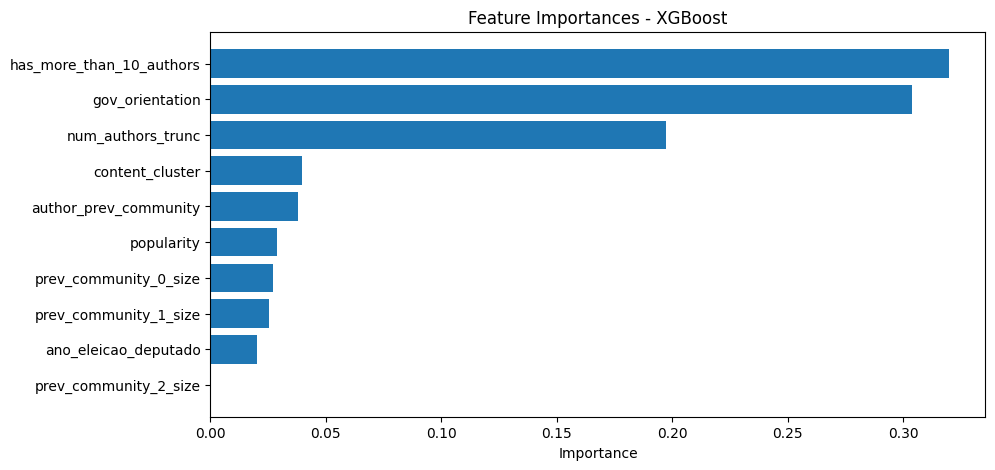

In [19]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_recall_curve, f1_score, classification_report, confusion_matrix, make_scorer, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import pandas as pd

print("Splitting X and y while keeping temporal order...")
X = dataset_features_target[features]
y = dataset_features_target[target]

# Identify numeric features for normalization
numeric_features = [
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'gov_orientation',
    'num_authors_trunc'
]

# Identify categorical/textual features
categorical_features = [f for f in features if f not in numeric_features]

print("Performing temporal split (80% train, 20% test)...")
split_idx = int(0.8 * len(X))
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Preparing documents for Doc2Vec (train only)...")
documents = [TaggedDocument(str(text).split(), [i]) for i, text in enumerate(X_train['content'])]

print("Training Doc2Vec model...")
doc2vec_model = Doc2Vec(vector_size=64, min_count=1, epochs=40, workers=4, seed=42)
doc2vec_model.build_vocab(documents)
doc2vec_model.train(documents, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

print("Inferring Doc2Vec vectors for train set...")
X_train_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_train['content']])

print("Clustering train vectors with KMeans...")
n_clusters = 8  # Adjust this value as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
X_train_clusters = kmeans.fit_predict(X_train_docvec)

print("Adding cluster column to X_train...")
X_train_with_cluster = X_train.copy()
X_train_with_cluster['content_cluster'] = X_train_clusters

print("Inferring Doc2Vec vectors for test set...")
X_test_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_test['content']])
print("Predicting clusters for test set...")
X_test_clusters = kmeans.predict(X_test_docvec)
X_test_with_cluster = X_test.copy()
X_test_with_cluster['content_cluster'] = X_test_clusters

print("Updating final feature list...")
final_features = [f for f in features if f != 'content'] + ['content_cluster']

print("Normalizing numeric features...")
scaler = StandardScaler()
X_train_scaled = X_train_with_cluster.copy()
X_test_scaled = X_test_with_cluster.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_with_cluster[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_with_cluster[numeric_features])

print("Selecting final features for the model...")
X_train_model = X_train_scaled[final_features]
X_test_model = X_test_scaled[final_features]

print("Defining F1 scorer for class 'Reprovada' (0)...")
f1_reprovada_scorer = make_scorer(f1_score, pos_label=0, average='binary')

# --------------- XGBoost ONLY ---------------
print("Starting GridSearch for XGBoost...")

# Função de callback para mostrar progresso do GridSearchCV
from sklearn.model_selection import ParameterGrid
import time

# Calcula o número total de combinações de parâmetros
neg, pos = y_train.value_counts()   # neg = reprov., pos = aprov.
scale_pos_weights = [1, neg / pos, 2*neg / pos, 3*neg / pos, 5*neg / pos]
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': scale_pos_weights,
    'subsample': [0.8, 1.0]
}
total_param_combinations = len(list(ParameterGrid(xgb_param_grid)))
cv_folds = 3
total_fits = total_param_combinations * cv_folds

print(f"GridSearchCV vai rodar {total_param_combinations} combinações de parâmetros x {cv_folds} folds = {total_fits} fits.")

# Callback para mostrar progresso do XGBoost (por fit)
from tqdm.notebook import tqdm

class VerboseGridSearchCV(GridSearchCV):
    def fit(self, X, y=None, **fit_params):
        # tqdm progress bar
        self._tqdm_bar = tqdm(total=total_fits, desc="GridSearch XGBoost Progress", leave=True)
        # Patch _fit_and_score to update tqdm
        from sklearn.model_selection._validation import _fit_and_score as orig_fit_and_score
        def _fit_and_score(*args, **kwargs):
            result = orig_fit_and_score(*args, **kwargs)
            self._tqdm_bar.update(1)
            return result
        import sklearn.model_selection._validation
        old_func = sklearn.model_selection._validation._fit_and_score
        sklearn.model_selection._validation._fit_and_score = _fit_and_score
        try:
            result = super().fit(X, y, **fit_params)
        finally:
            sklearn.model_selection._validation._fit_and_score = old_func
            self._tqdm_bar.close()
        return result

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
y_train_inv = 1 - y_train
y_test_inv = 1 - y_test

xgb_grid = VerboseGridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_model, y_train_inv)
print(f"XGBoost (GridSearch) best F1_reprovada: {xgb_grid.best_score_:.4f} with params: {xgb_grid.best_params_}")
xgb_best = xgb_grid.best_estimator_
y_proba_inv = xgb_best.predict_proba(X_test_model)[:, 1]
prec_inv, rec_inv, thresh_inv = precision_recall_curve(y_test_inv, y_proba_inv, pos_label=1)
f1_neg_inv = 2 * (prec_inv * rec_inv) / (prec_inv + rec_inv)
best_idx_inv = f1_neg_inv.argmax()
best_thresh_inv = thresh_inv[best_idx_inv] if best_idx_inv < len(thresh_inv) else 0.5
print(f"Best F1_reprovada = {f1_neg_inv[best_idx_inv]:.3f} at threshold={best_thresh_inv:.2f}")

y_pred_xgb_f1neg = (y_proba_inv >= best_thresh_inv).astype(int)
y_pred_xgb_f1neg = 1 - y_pred_xgb_f1neg

print("\nConfusion matrix (XGBoost, optimal threshold for F1_reprovada):")
print(confusion_matrix(y_test, y_pred_xgb_f1neg))
print(classification_report(y_test, y_pred_xgb_f1neg, digits=3, target_names=["Reprovada","Aprovada"]))

xgb_auroc = roc_auc_score(y_test, 1 - y_proba_inv)
print(f"XGBoost AUROC (test): {xgb_auroc:.4f}")

# ----------------- ADD XGBOOST PREDICTIONS TO merged_df -----------------
print("Adding XGBoost predictions to merged_df...")

# 1. Get the indices/ids of the test samples
if 'id' in X_test.columns and 'id' in merged_df.columns:
    print("Using 'id' column from X_test and merged_df for alignment.")
    test_ids = X_test['id'].values
elif 'id' in merged_df.columns:
    print("Using X_test index to fetch 'id' from merged_df.")
    test_ids = X_test.index
else:
    print("No 'id' column found, using index.")
    test_ids = X_test.index

# 2. Get model predictions for the test set (using optimal threshold for F1_reprovada)
y_pred_xgb_final = y_pred_xgb_f1neg

# 3. Create a Series with results, indexed by ids
pred_series = pd.Series(y_pred_xgb_final, index=test_ids, name='aprovacao_predita_xgb')

# 4. Add prediction column to merged_df
if 'id' in merged_df.columns:
    if 'id' not in X_test.columns:
        print("Adjusting prediction Series index to match real 'id' values in merged_df.")
        test_ids_real = merged_df.loc[test_ids, 'id']
        pred_series.index = test_ids_real
    # Remove old column if it exists to avoid merge suffix error
    if 'aprovacao_predita_xgb' in merged_df.columns:
        print("Removing existing 'aprovacao_predita_xgb' column from merged_df to avoid merge conflict.")
        merged_df = merged_df.drop(columns=['aprovacao_predita_xgb'])
    print("Merging predictions into merged_df...")
    merged_df = merged_df.merge(pred_series, left_on='id', right_index=True, how='left')
else:
    print("Adding 'aprovacao_predita_xgb' column directly to merged_df (no 'id' column).")
    merged_df['aprovacao_predita_xgb'] = pred_series

print("Predictions added to merged_df.")

# ----------------- XGBOOST FEATURE IMPORTANCE -----------------
import matplotlib.pyplot as plt

print("Calculating XGBoost feature importances...")
importances = xgb_best.feature_importances_
feature_names = X_train_model.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature importances (XGBoost):")
print(importance_df)

plt.figure(figsize=(10,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


In [20]:
merged_df_preditos = merged_df[merged_df['aprovacao_predita_xgb'].notna()]


In [21]:
merged_df_preditos

,id,data,siglaOrgao,aprovacao,year,GOV.,Governo,Oposição,author_type,num_authors,...,popularity,author_prev_community,prev_community_0_size,prev_community_1_size,prev_community_2_size,gov_orientation,ano_eleicao_deputado,num_authors_trunc,has_more_than_10_authors,aprovacao_predita_xgb
9018995,2279513-42,2021-08-10,PLEN,0,2021,-1,0,1,Órgão do Poder Executivo,24,...,0.422992,-1.0,441,155,0,-1,False,10,True,0.0
9018999,2279513-56,2021-08-10,PLEN,0,2021,0,0,0,Órgão do Poder Executivo,24,...,0.422992,-1.0,441,155,0,0,False,10,True,1.0
9019003,2279513-58,2021-08-10,PLEN,1,2021,0,0,0,Órgão do Poder Executivo,24,...,0.000000,-1.0,441,155,0,0,False,10,True,1.0
9019007,2279513-59,2021-08-10,PLEN,1,2021,0,0,0,Órgão do Poder Executivo,24,...,0.000000,-1.0,441,155,0,0,False,10,True,1.0
9019011,2279513-62,2021-08-10,PLEN,0,2021,0,0,0,Órgão do Poder Executivo,24,...,0.000000,-1.0,441,155,0,0,False,10,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17793763,2473375-59,2024-12-19,PLEN,1,2024,0,1,-1,Deputado(a),252,...,0.503866,0.0,392,198,0,1,False,10,True,1.0
17799595,2473375-80,2024-12-19,PLEN,1,2024,0,0,0,Deputado(a),252,...,0.000000,0.0,392,198,0,0,False,10,True,1.0
17802511,2460010-35,2024-12-19,PLEN,0,2024,0,-1,1,Deputado(a),6,...,0.427785,0.0,392,198,0,-1,False,6,False,0.0
17802515,2460010-43,2024-12-19,PLEN,1,2024,0,1,-1,Deputado(a),6,...,0.427785,0.0,392,198,0,1,False,6,False,1.0


In [22]:
# Cria uma coluna para identificar o tipo de predição (VP, VN, FP, FN)
# Considerando que 'aprovacao' é o valor real e 'aprovacao_predita_xgb' é a previsão

def classificar_predicao(row):
    real = row['aprovacao']
    pred = row['aprovacao_predita_xgb']
    if real == 1 and pred == 1:
        return 'Verdadeiro Positivo'
    elif real == 0 and pred == 0:
        return 'Verdadeiro Negativo'
    elif real == 0 and pred == 1:
        return 'Falso Positivo'
    elif real == 1 and pred == 0:
        return 'Falso Negativo'
    else:
        return 'Outro'

merged_df_preditos['tipo_predicao'] = merged_df_preditos.apply(classificar_predicao, axis=1)

# Agora, crie uma tabela (DataFrame) com cada grupo
tabela_predicoes = merged_df_preditos.groupby('tipo_predicao').size().reset_index(name='quantidade')
tabela_predicoes


C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_40608\219703434.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_preditos['tipo_predicao'] = merged_df_preditos.apply(classificar_predicao, axis=1)


,tipo_predicao,quantidade
0,Falso Negativo,77
1,Falso Positivo,297
2,Verdadeiro Negativo,457
3,Verdadeiro Positivo,3210


In [23]:
# Agrupa por 'theme' e 'tipo_predicao' e conta a quantidade de cada combinação
tabela_tema_predicao = merged_df_preditos.groupby(['theme', 'tipo_predicao']).size().reset_index(name='quantidade')

# Pivot para facilitar visualização: linhas = tema, colunas = tipo_predicao
tabela_tema_predicao_pivot = tabela_tema_predicao.pivot(index='theme', columns='tipo_predicao', values='quantidade').fillna(0).astype(int)

# Garante que todas as colunas estejam presentes
for col in ['Falso Negativo', 'Falso Positivo', 'Verdadeiro Positivo', 'Verdadeiro Negativo']:
    if col not in tabela_tema_predicao_pivot.columns:
        tabela_tema_predicao_pivot[col] = 0

# Calcula o % de erro para cada tema
tabela_tema_predicao_pivot['percentual_erro'] = (
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo']) /
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo'] +
     tabela_tema_predicao_pivot['Verdadeiro Positivo'] + tabela_tema_predicao_pivot['Verdadeiro Negativo'])
).fillna(0)

# Ranqueia do menor para o maior percentual de erro
tabela_tema_predicao_rank = tabela_tema_predicao_pivot.sort_values('percentual_erro', ascending=True)

# Exibe a tabela ranqueada com os valores de VP, VN, FP, FN e percentual de erro
tabela_tema_predicao_rank[['percentual_erro', 'Verdadeiro Positivo', 'Verdadeiro Negativo', 'Falso Positivo', 'Falso Negativo']]


tipo_predicao,percentual_erro,Verdadeiro Positivo,Verdadeiro Negativo,Falso Positivo,Falso Negativo
theme,,,,,
Homenagens e Datas Comemorativas,0.000000,61,0,0,0
Turismo,0.000000,5,0,0,0
"Arte, Cultura e Religião",0.022222,81,7,2,0
Relações Internacionais e Comércio Exterior,0.022624,210,6,5,0
"Indústria, Comércio e Serviços",0.038462,23,2,0,1
Esporte e Lazer,0.045455,40,2,1,1
Defesa e Segurança,0.048000,118,1,5,1
Cidades e Desenvolvimento Urbano,0.060241,61,17,4,1
Processo Legislativo e Atuação Parlamentar,0.062500,45,0,1,2


In [ ]:
# Agrupa por 'theme' e 'tipo_predicao' e conta a quantidade de cada combinação
tabela_tema_predicao = merged_df_preditos.groupby(['legislatura', 'tipo_predicao']).size().reset_index(name='quantidade')

# Pivot para facilitar visualização: linhas = tema, colunas = tipo_predicao
tabela_tema_predicao_pivot = tabela_tema_predicao.pivot(index='legislatura', columns='tipo_predicao', values='quantidade').fillna(0).astype(int)

# Garante que todas as colunas estejam presentes
for col in ['Falso Negativo', 'Falso Positivo', 'Verdadeiro Positivo', 'Verdadeiro Negativo']:
    if col not in tabela_tema_predicao_pivot.columns:
        tabela_tema_predicao_pivot[col] = 0

# Calcula o % de erro para cada tema
tabela_tema_predicao_pivot['percentual_erro'] = (
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo']) /
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo'] +
     tabela_tema_predicao_pivot['Verdadeiro Positivo'] + tabela_tema_predicao_pivot['Verdadeiro Negativo'])
).fillna(0)

# Ranqueia do menor para o maior percentual de erro
tabela_tema_predicao_rank = tabela_tema_predicao_pivot.sort_values('percentual_erro', ascending=True)

# Exibe a tabela ranqueada com os valores de VP, VN, FP, FN e percentual de erro
tabela_tema_predicao_rank[['percentual_erro', 'Verdadeiro Positivo', 'Verdadeiro Negativo', 'Falso Positivo', 'Falso Negativo']]

tipo_predicao,percentual_erro,Verdadeiro Positivo,Verdadeiro Negativo,Falso Positivo,Falso Negativo
legislatura,,,,,
57,0.070541,1938,157,131,28
56,0.120313,1272,300,166,49
